In [31]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math
from datetime import date, datetime, timedelta
import kagglehub

In [32]:
# Download latest version
path = kagglehub.dataset_download("tranhuunhan/vietnam-bank-churn-dataset-2025")
print("Path to dataset files:", path)
csv_file = os.listdir(path)[0]
print(csv_file)
full_path = os.path.join(path, csv_file)
print(full_path)

Path to dataset files: /Users/hanhnh1002/.cache/kagglehub/datasets/tranhuunhan/vietnam-bank-churn-dataset-2025/versions/1
bank_churn_dataset_80k.csv
/Users/hanhnh1002/.cache/kagglehub/datasets/tranhuunhan/vietnam-bank-churn-dataset-2025/versions/1/bank_churn_dataset_80k.csv


In [33]:
pd.set_option('display.max_columns', None)
df = pd.read_csv(full_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      80000 non-null  int64  
 1   full_name               80000 non-null  object 
 2   credit_sco              80000 non-null  int64  
 3   gender                  80000 non-null  object 
 4   age                     80000 non-null  int64  
 5   occupation              80000 non-null  object 
 6   balance                 80000 non-null  int64  
 7   monthly_ir              80000 non-null  int64  
 8   address                 80000 non-null  object 
 9   origin_province         80000 non-null  object 
 10  tenure_ye               80000 non-null  int64  
 11  married                 80000 non-null  int64  
 12  nums_card               80000 non-null  int64  
 13  nums_service            80000 non-null  int64  
 14  active_member           80000 non-null

In [34]:
print( 'Dataset has no null value? :', (df.isna().sum() == 0).all())

Dataset has no null value? : True


In [35]:
df = df.set_index('id')
drop_cols = ['full_name', 'address', 'occupation', 'origin_province', 'cluster_group', 'married']
df = df.drop(columns = drop_cols, axis = 1)
df.head()

,credit_sco,gender,age,balance,monthly_ir,tenure_ye,nums_card,nums_service,active_member,last_active_date,last_transaction_month,created_date,exit,customer_segment,engagement_score,loyalty_level,digital_behavior,risk_score,risk_segment
id,,,,,,,,,,,,,,,,,,,
1,725,male,55,177306004,121000000,0,4,8,True,03/04/2025,91038993,27/02/2025,False,Priority,90,Bronze,mobile,0.0359,Low
2,689,male,45,1927416,5000000,3,3,2,True,14/05/2025,3255569,29/07/2021,False,Mass,63,Gold,mobile,0.2664,Low
3,702,female,44,304931745,109000000,4,2,8,False,10/09/2021,0,03/03/2021,False,Priority,36,Silver,offline,0.1343,Low
4,766,male,44,50615501,79000000,3,4,3,False,04/03/2025,0,12/02/2022,False,Priority,23,Bronze,offline,0.2185,Low
5,677,female,77,40532432,25000000,2,4,3,False,06/08/2022,0,24/07/2022,False,Emerging,23,Bronze,offline,0.2942,Low


In [36]:
df[df['risk_segment']==1]

,credit_sco,gender,age,balance,monthly_ir,tenure_ye,nums_card,nums_service,active_member,last_active_date,last_transaction_month,created_date,exit,customer_segment,engagement_score,loyalty_level,digital_behavior,risk_score,risk_segment
id,,,,,,,,,,,,,,,,,,,


> ## 1. EDA

#### ***Convert data type***

In [37]:
# Boolean to integer

bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

In [38]:
# Date string to integer

df['days_since_last_active'] = (pd.Timestamp.today() - pd.to_datetime(df['last_active_date'], format = '%d/%m/%Y')).dt.days
df['days_since_created'] = (pd.Timestamp.today() - pd.to_datetime(df['created_date'], format = '%d/%m/%Y')).dt.days
df = df.drop(columns = ['last_active_date', 'created_date'])

In [39]:
# Target columns

df['risk_segment'] = df['risk_segment'].map({'Low': 0, 'Medium':1})

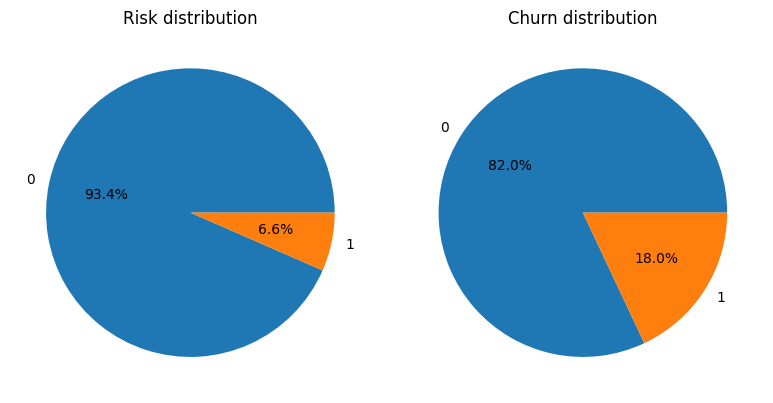

In [40]:
# Visualize target columns 

fig, (ax1, ax2) = plt.subplots(figsize = (8,4), nrows = 1, ncols = 2)
ax1.pie(df['risk_segment'].value_counts().values, 
        labels = df['risk_segment'].value_counts().index,
        autopct = '%1.1f%%')
ax1.set_title('Risk distribution')

ax2.pie(df['exit'].value_counts().values, 
        labels = df['exit'].value_counts().index,
        autopct = '%1.1f%%')
ax2.set_title('Churn distribution')
plt.tight_layout()
plt.show()

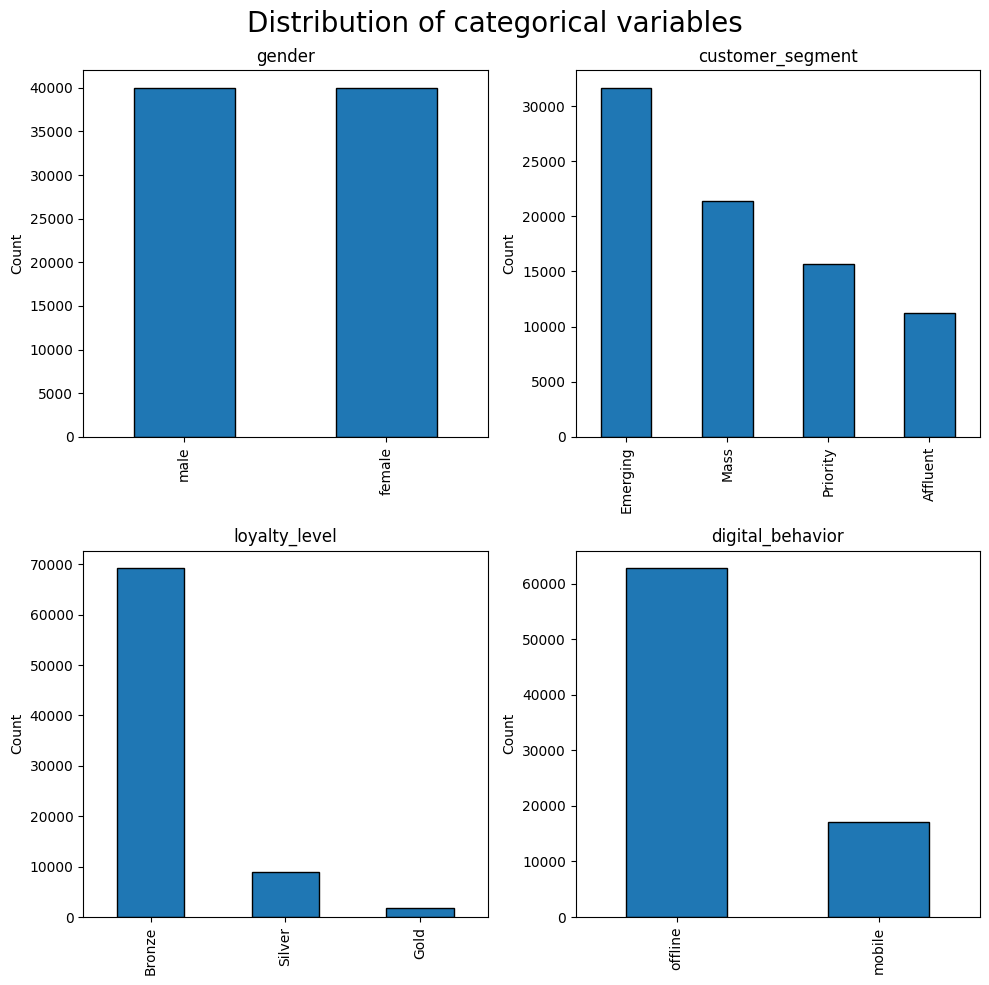

In [41]:
# Function to visualize all categorial variables

columns =  df.select_dtypes(include=['object']).columns
not_include_cols = ['last_active_date', 'created_date', 'risk_segment']
plot_cols = [i for i in columns if i not in not_include_cols ]

n = len(plot_cols)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Distribution of categorical variables', fontsize=20)
plt.tight_layout()
plt.show()

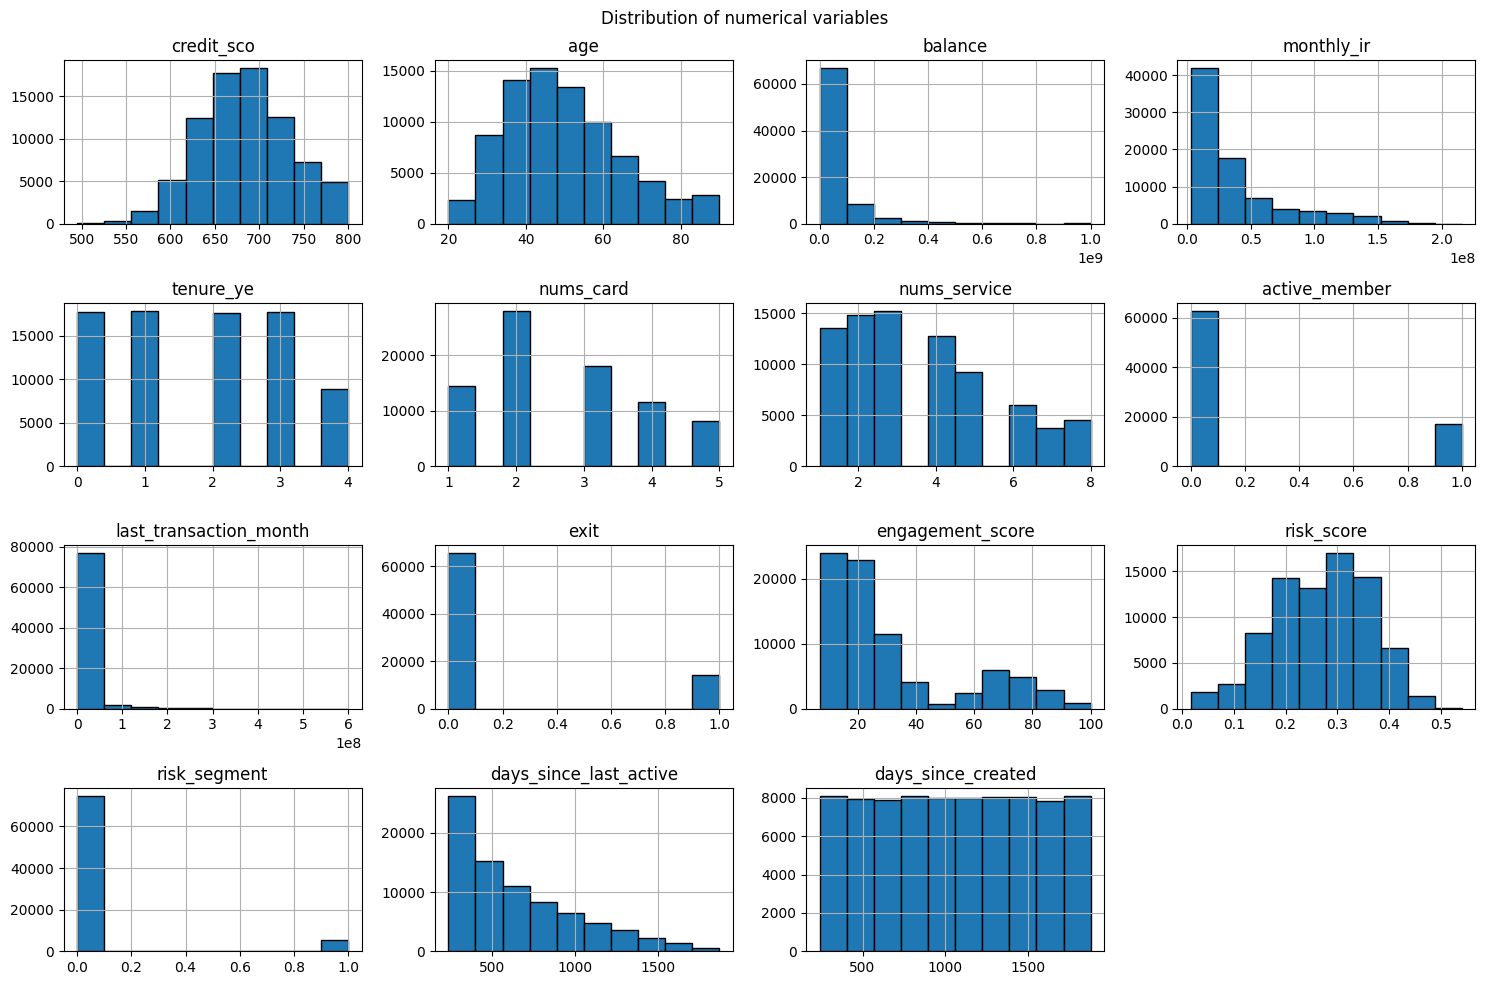

In [42]:
plot_cols =  df.select_dtypes(include='number').columns
df[plot_cols].hist(bins = 10, edgecolor = 'black', figsize=(15, 10) )
plt.suptitle('Distribution of numerical variables')
plt.tight_layout()
plt.show()

> ## 2. Split test/train

In [43]:
from sklearn.model_selection import train_test_split
target_cols = ['exit', 'risk_score', 'risk_segment', 'credit_sco']
y = df['risk_segment']
X = df.drop(columns = target_cols)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=10, stratify=y)
X_train.head(5)

,gender,age,balance,monthly_ir,tenure_ye,nums_card,nums_service,active_member,last_transaction_month,customer_segment,engagement_score,loyalty_level,digital_behavior,days_since_last_active,days_since_created
id,,,,,,,,,,,,,,,
57,male,38,59232333,55000000,3,3,4,0,0,Affluent,24,Bronze,offline,1068,1339
13302,male,41,15162655,17000000,2,2,1,0,0,Emerging,10,Bronze,offline,1017,1285
63733,male,57,4048242,5000000,0,1,1,1,3727331,Mass,54,Bronze,mobile,269,295
13726,male,26,19806524,18000000,1,5,3,1,8199961,Emerging,71,Silver,mobile,307,836
70757,male,34,4955875,7000000,2,2,4,0,0,Mass,21,Bronze,offline,588,1001


> ## 3. Data Preprocessing

#### ***Data encoding***

In [44]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_cols = ['loyalty_level', 'customer_segment']
binary_cols = ['gender', 'digital_behavior']

ordinal_encoder = OrdinalEncoder(categories=[['Bronze', 'Silver', 'Gold'], 
                                            ['Mass', 'Emerging', 'Priority', 'Affluent']])

binary_encoder = OrdinalEncoder() 

X_train[ordinal_cols] = ordinal_encoder.fit_transform(X_train[ordinal_cols])
X_train[binary_cols] = binary_encoder.fit_transform(X_train[binary_cols])
X_test[ordinal_cols] = ordinal_encoder.transform(X_test[ordinal_cols])
X_test[binary_cols] = binary_encoder.transform(X_test[binary_cols])


In [45]:
X_train.sample(5)

,gender,age,balance,monthly_ir,tenure_ye,nums_card,nums_service,active_member,last_transaction_month,customer_segment,engagement_score,loyalty_level,digital_behavior,days_since_last_active,days_since_created
id,,,,,,,,,,,,,,,
33159,0.0,33,160534026,69000000,4,4,3,0,0,2.0,23,0.0,1.0,1610,1735
64944,1.0,62,906603757,61000000,2,5,6,0,0,2.0,38,1.0,1.0,873,1310
1105,0.0,39,344685080,113000000,2,2,7,0,0,2.0,32,0.0,1.0,835,1154
41208,0.0,86,48297219,23000000,2,2,1,0,0,1.0,10,0.0,1.0,610,1262
46394,0.0,44,114796299,141000000,2,3,1,0,0,2.0,13,0.0,1.0,431,1070


In [46]:
print( 'All variables are numeric? :' , (len(X_train.select_dtypes(include='number').columns) - len(X_train.columns)) == 0)

All variables are numeric? : True


#### ***Data scaling***: <mark> Generally not required for tree-based models 🌳 <mark>

> ## 4. Feature selection

#### ***Correlation***

Text(0.5, 1.0, 'Covariance Heatmap of X_train')

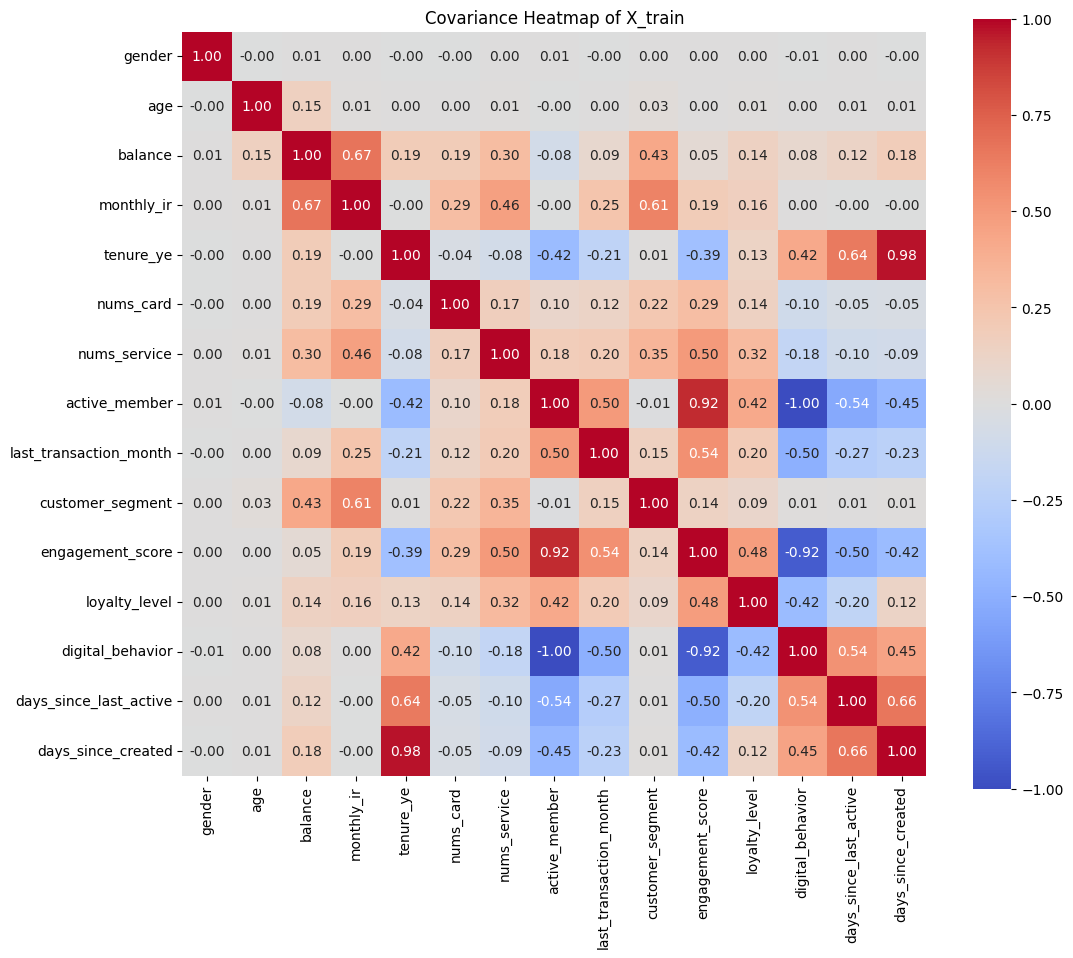

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

cor_matrix = X_train.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(cor_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Covariance Heatmap of X_train')

In [48]:
# Drop columns due to high correlation

col_to_drop = ['tenure_ye', 'engagement_score']
X_train =X_train.drop(columns = col_to_drop )
X_test = X_test.drop(columns = col_to_drop)

#### ***Mutual information***

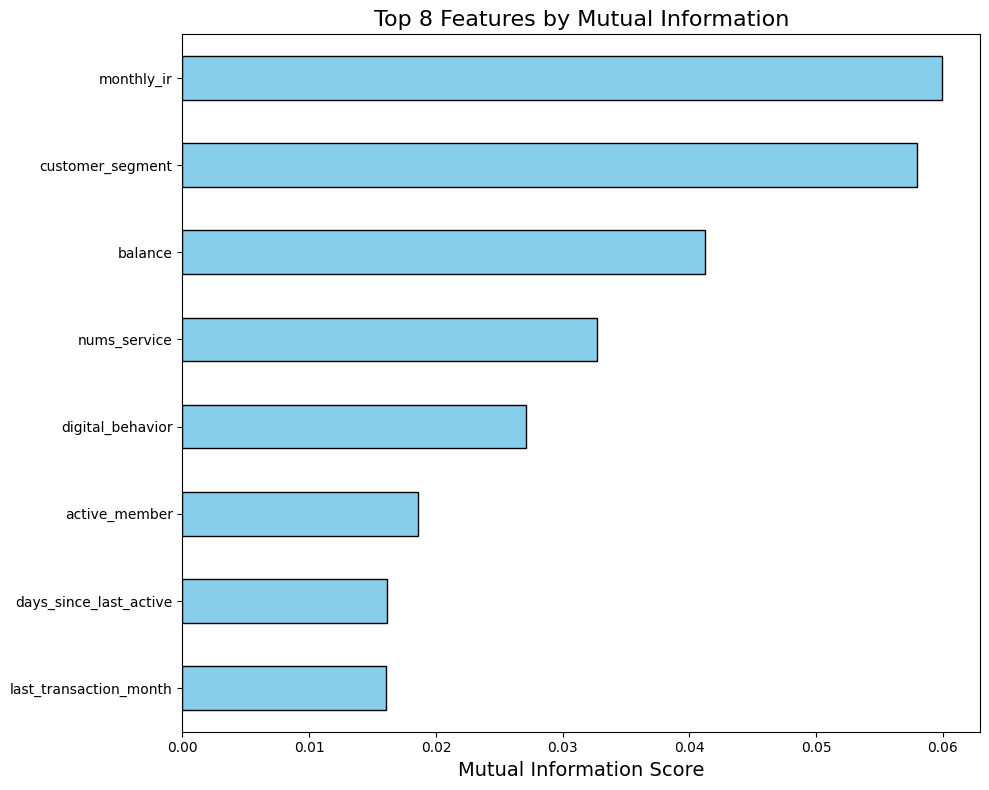

In [49]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
MI = mutual_info_classif(X_train, y_train, random_state=10)
k_feature = 8
top_k_features = pd.Series(MI, index=X_train.columns).sort_values(ascending=False).head(k_feature)
top_k_features = top_k_features.sort_values(ascending = True)
plt.figure(figsize=(10, 8))
top_k_features.plot.barh(color='skyblue', edgecolor = 'black')
plt.title(f'Top {k_feature} Features by Mutual Information', fontsize=16)
plt.xlabel('Mutual Information Score', fontsize=14)
plt.tight_layout()
plt.show()

In [50]:
X_train = X_train[top_k_features.index]
X_test = X_test[top_k_features.index]
X_test.to_csv('X_test_data.csv')

In [51]:
X_test.head()

,last_transaction_month,days_since_last_active,active_member,digital_behavior,nums_service,balance,customer_segment,monthly_ir
id,,,,,,,,
35631,14677685,275,1,0.0,2,4252113,0.0,12000000
35117,0,687,0,1.0,1,61425659,1.0,22000000
5698,0,538,0,1.0,2,107545271,1.0,19000000
49132,0,433,0,1.0,2,15813059,3.0,40000000
74651,95785853,253,1,0.0,8,49479407,2.0,85000000


> ## 5.Model training: Random Forest | XGB

#### ***Hyperparameter tuning***

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix,  roc_curve, auc, precision_recall_curve
import xgboost as xgb

rf_model  = RandomForestClassifier()
xgb_model = xgb.XGBClassifier()

param_dist_rf = {
    "n_estimators": [300, 380, 450, 550],
    "max_depth": [None, 3, 5, 7, 10],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [2, 3, 4, 6],
    "max_features": ["sqrt", 0.4, 0.6], 
    "bootstrap": [True],
    "class_weight": ["balanced_subsample"],
}

param_dist_xgb = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 3, 5, 7, 12],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 1], 
    "colsample_bytree": [0.7,1]
}

In [53]:
def train_model(model, param_grid, X_train, y_train):
    search = RandomizedSearchCV(model, param_grid, cv = 3, scoring = 'roc_auc', n_iter=10,
                                n_jobs = -1, verbose = 1, random_state = 10, refit = True)
    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    best_params = search.best_params_
    best_scores = search.best_score_
    print(f"Best params: {best_params}")
    print(f"Best CV AUC: {best_scores:.4f}")
    return best_model

In [54]:
def plot_roc(model, X_test, y_test, model_name):
    plt.figure(figsize=(8, 6))
    scores = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"(AUC={roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
    plt.title(f"ROC Curves on Test Set ({model_name})", fontsize=16)
    plt.xlabel("False Positive Rate", fontsize=14)
    plt.ylabel("True Positive Rate", fontsize=14)
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'{model_name}_roc_curve.png')
    plt.show()

In [55]:
def plot_precision_recall(model,X_test, y_test, model_name):
    scores = model.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, scores)
    thresholds_full = np.concatenate(([0], thresholds))
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds_full, precision, label="Precision")
    plt.plot(thresholds_full, recall, label="Recall")
    plt.xlabel("Decision Threshold")
    plt.ylabel("Score")
    plt.title(f"Precision & Recall Trade Off ({model_name})")
    plt.legend()
    plt.grid(True)
    plt.legend()
    plt.show()

In [56]:
def plot_cm(model, X_test, y_test, model_name):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Risk', 'Risk'], yticklabels=['No Risk', 'Risk'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix with standard Threshold ({model_name})')
    plt.show()
    tp = cm[1][1]
    fp = cm[0][1]
    tn = cm[0][0]
    fn = cm[1][0]
    print('Precision:', tp / (tp + fp) * 100, '%' )
    print('Recall:', tp / (tp + fn) * 100, '%')
        

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'n_estimators': 380, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'max_depth': 7, 'class_weight': 'balanced_subsample', 'bootstrap': True}
Best CV AUC: 0.9190


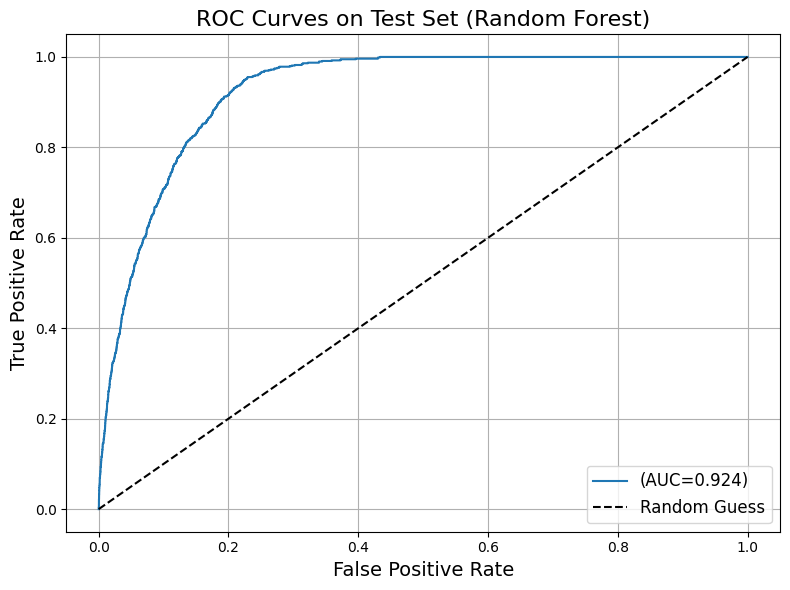

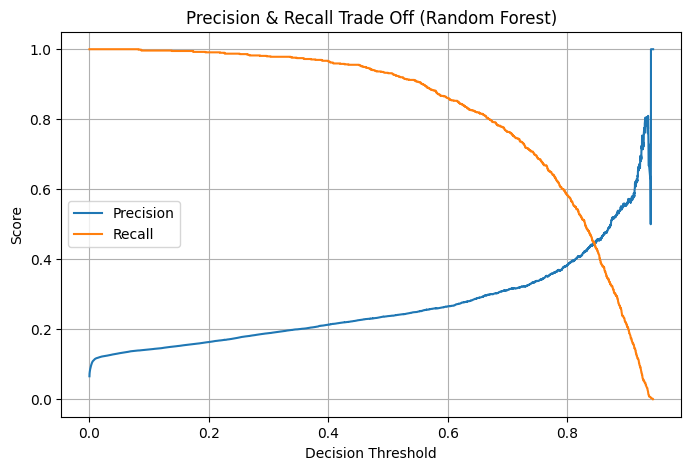

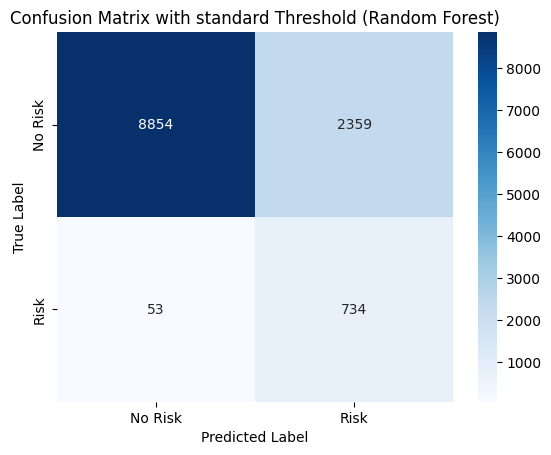

Precision: 23.731005496281927 %
Recall: 93.26556543837357 %


In [57]:
best_rf = train_model(rf_model, param_dist_rf, X_train, y_train)
plot_roc(best_rf, X_test, y_test, 'Random Forest')
plot_precision_recall(best_rf, X_test, y_test,'Random Forest')
plot_cm(best_rf, X_test, y_test,'Random Forest')


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best CV AUC: 0.9195


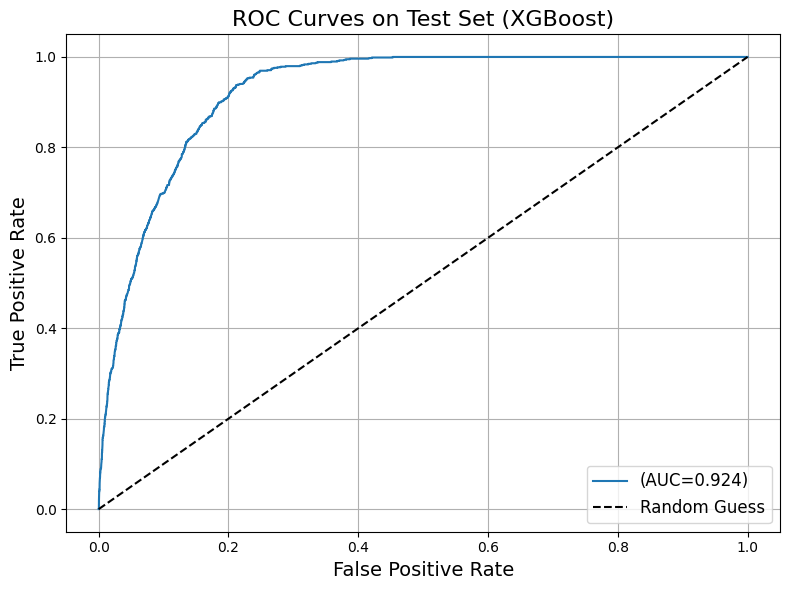

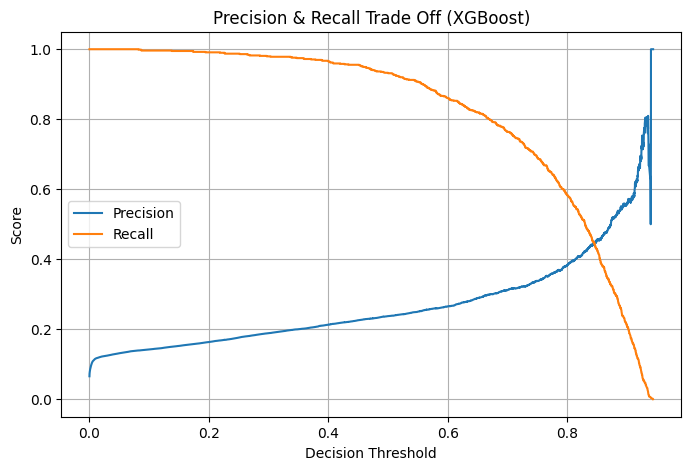

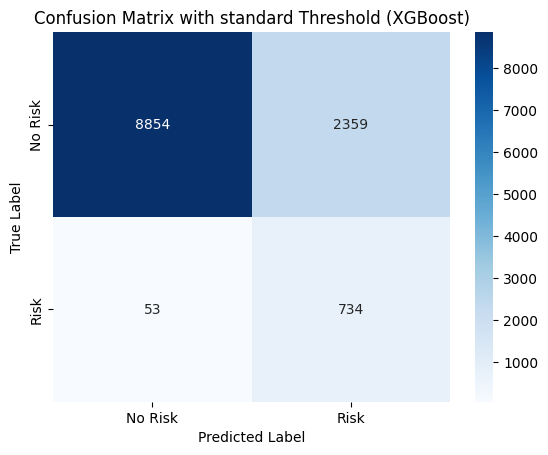

Precision: 23.731005496281927 %
Recall: 93.26556543837357 %


In [58]:
best_xgb = train_model(xgb_model, param_dist_xgb, X_train, y_train)
plot_roc(best_xgb, X_test, y_test, 'XGBoost')
plot_precision_recall(best_rf, X_test, y_test,'XGBoost')
plot_cm(best_rf, X_test, y_test,'XGBoost')

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'n_estimators': 550, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced_subsample', 'bootstrap': True}
Best CV AUC: 0.9184


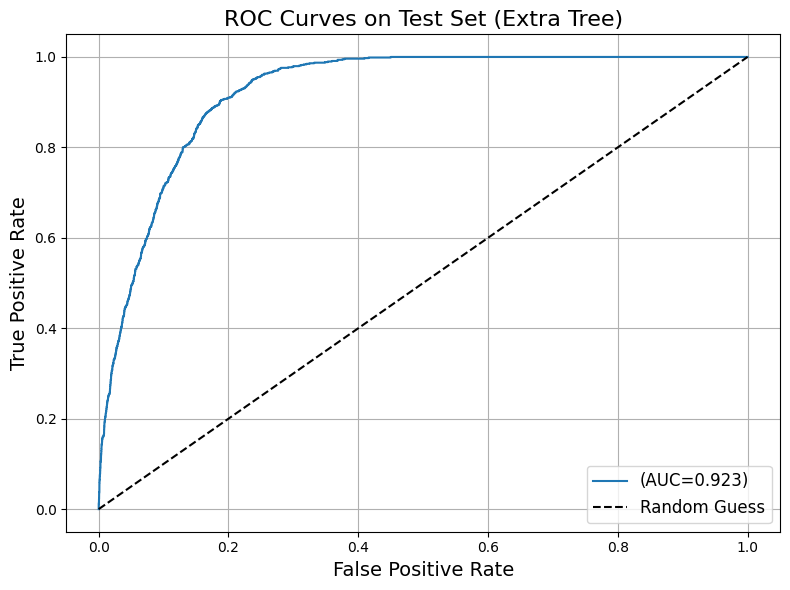

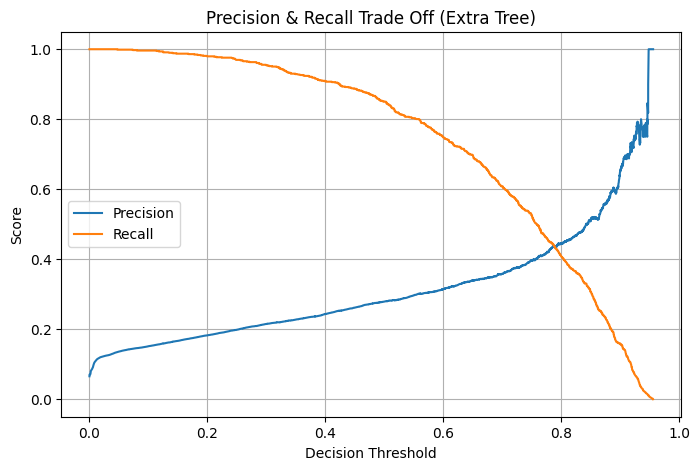

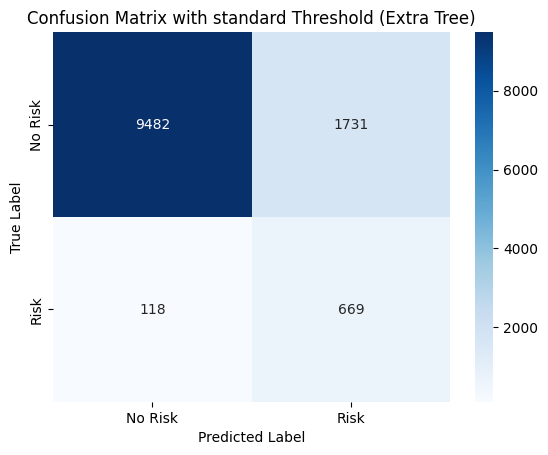

Precision: 27.875 %
Recall: 85.00635324015248 %


In [59]:
from sklearn.ensemble import ExtraTreesClassifier
et = ExtraTreesClassifier(random_state = 10, class_weight = 'balance')
best_et = train_model(et, param_dist_rf, X_train, y_train)
plot_roc(best_et, X_test, y_test, 'Extra Tree')
plot_precision_recall(best_et, X_test, y_test,'Extra Tree')
plot_cm(best_et, X_test, y_test,'Extra Tree')

In [60]:
import joblib
joblib.dump(best_rf, 'rf_credit_risk_model.pkl')

['rf_credit_risk_model.pkl']